<font color = green >

## Home Task: Implement K-means algorithm

</font>


<font color = green >

###  Data 

</font>



In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_classification

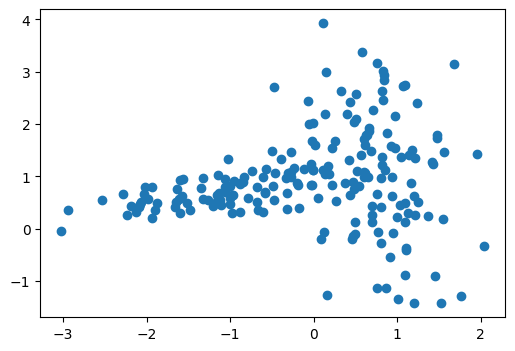

In [2]:
Xc_2,_= make_classification(
    n_samples=200, n_features=2, n_informative=2, n_redundant=0,
    random_state=0, n_clusters_per_class=1, class_sep=0.8)

plt.figure(figsize=(6, 4))
plt.scatter(Xc_2[:,0], Xc_2[:,1])
plt.show()

<font color = green >

###  Steps of implementatiion

</font>

1) Initialize $K$ centroids 

2) Assign every point to closest centroid 

3) Compute new centroids as means of samples assigned to corresponding centroid

4) Implement cost $J = \frac{1}{m}\underset{i}{\sum}(d^{(i)})^{2}$ where $d^{(i)}$ is distance from sample $x^{(i)}$ to assigned centroid $c^{(i)}$

5) Iterate setps 2,3 till cost is stabile 

6) Select the best clustering (with the least cost) from 100 results computed with random centroid  initializations 

7) Visualize results (clusters, centroids) for $K=4$

Note: 
* You may  need develop couple of additional/intermediate functions
* You may track cost changes to make sure the algorithm is working properly 

In [3]:
def initialize_centroids(X, K, seed=0):
    # Randomly select K unique data points as initial centroids
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(X), K, replace=False) 
    return X[idx].copy() # copy to avoid modifying the original data

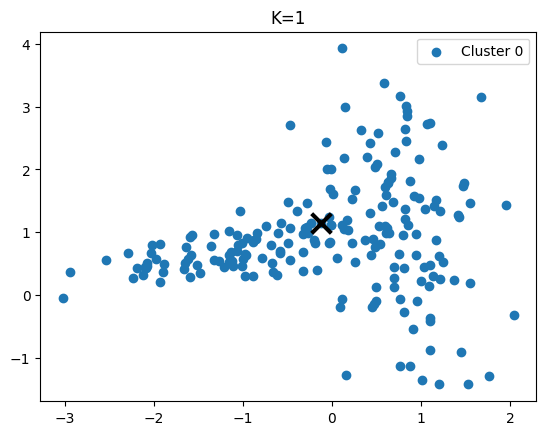

In [4]:
def plot_clusters(X, centroids=None, labels=None):
    if labels is None:
        labels = np.zeros(len(X), dtype=int)
    K = len(centroids) if centroids is not None else 0
    #colors = plt.get_cmap('Paired', K)
    
    for k in range(K):
        members = X[labels == k]
        plt.scatter(members[:, 0], members[:, 1], label=f'Cluster {k}')
    
    for i, centroid in enumerate(centroids):
        plt.scatter(centroid[0], centroid[1], color='black', s=200, marker='x', linewidths=3)
    
    plt.legend()
    plt.title(f'K={K}')
    plt.show()
plot_clusters(Xc_2, initialize_centroids(Xc_2, 1, seed=0))

In [5]:
def assign_clusters(X, centroids):
    # Calculate the distance from each point to each centroid
    diffs = X[:, np.newaxis, :] - centroids[np.newaxis, :, :]
    sq_distances = np.sum(diffs ** 2, axis=2)
    # Assign each point to the nearest centroid
    labels = np.argmin(sq_distances, axis=1) 
    return labels

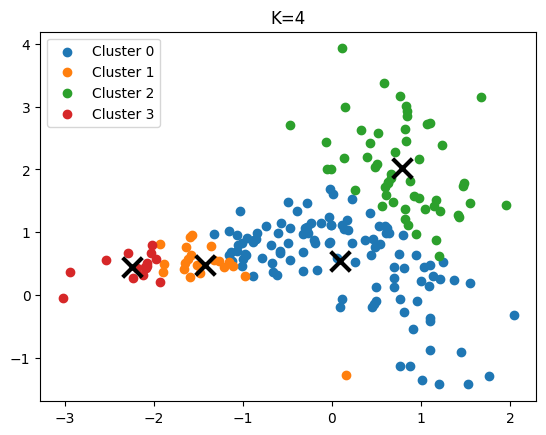

In [6]:
def compute_centroids(X, labels, K):
    # Compute the mean of points in each cluster to get new centroids
    centroids = np.zeros((K, X.shape[1]))
    for k in range(K):
        centroids[k] = X[labels == k].mean(axis=0)
    return centroids

plot_clusters(Xc_2, compute_centroids(Xc_2, assign_clusters(Xc_2, initialize_centroids(Xc_2, 4, seed=0)), 4), assign_clusters(Xc_2, initialize_centroids(Xc_2, 4, seed=0)))

In [7]:
def J_cost(X, labels, centroids):
    # J = (1/m) * sum of squared distances from each point to its centroid
    m = len(X)
    total = 0.0
    for k in range(len(centroids)):
        members = X[labels == k]
        if len(members) > 0:
            diffs = members - centroids[k]
            total += np.sum(diffs ** 2)
    return total / m

labels = assign_clusters(Xc_2, initialize_centroids(Xc_2, 4, seed=0))
centroids = compute_centroids(Xc_2, labels, 4)
cost = J_cost(Xc_2, labels, centroids)
print(f'Cost J: {cost:.5f}')

Cost J: 0.83634


In [8]:
def run_kmeans(X, K, seed=0, max_iter=100):
    centroids = initialize_centroids(X, K, seed=seed)
    J_history = []
    # Iteratively assign clusters and update centroids
    for _ in range(max_iter):
        labels = assign_clusters(X, centroids)
        centroids = compute_centroids(X, labels, K)
        j = J_cost(X, labels, centroids)
        J_history.append(j)

    return centroids, labels, J_history

In [9]:
def best_kmeans(X, K=1, n_runs=100):
    # Run K-means multiple times and keep the best result (lowest cost)
    best_centroids, best_labels, best_J_hist = None, None, None

    for i in range(n_runs):
        centroids, labels, J_hist = run_kmeans(X, K, seed=i)
        if best_J_hist is None or J_hist[-1] < best_J_hist[-1]:
            best_centroids = centroids
            best_labels = labels
            best_J_hist = J_hist

    return best_centroids, best_labels, best_J_hist

best_centroids, best_labels, best_J_history = best_kmeans(Xc_2, K=4, n_runs=100)
best_centroids, best_labels, best_J_history[-1]

(array([[ 0.96220912, -0.18860474],
        [-1.46901201,  0.59888478],
        [ 0.76885808,  2.14333659],
        [ 0.0467027 ,  0.99993105]]),
 array([0, 3, 2, 0, 1, 1, 2, 1, 1, 2, 3, 0, 2, 3, 1, 1, 3, 0, 1, 2, 1, 0,
        3, 3, 0, 0, 3, 0, 1, 0, 2, 1, 1, 1, 1, 3, 0, 1, 1, 2, 1, 3, 3, 0,
        3, 1, 1, 3, 0, 3, 0, 0, 2, 1, 2, 2, 1, 1, 3, 2, 0, 1, 0, 1, 3, 3,
        3, 3, 3, 0, 0, 3, 3, 0, 1, 3, 3, 2, 2, 1, 0, 3, 1, 1, 2, 3, 3, 2,
        2, 2, 1, 2, 2, 2, 1, 0, 0, 2, 3, 2, 2, 1, 0, 3, 1, 1, 1, 1, 1, 2,
        1, 2, 1, 2, 1, 3, 2, 2, 1, 2, 0, 2, 2, 1, 0, 3, 1, 2, 3, 1, 3, 2,
        3, 3, 3, 0, 3, 2, 3, 0, 3, 3, 3, 1, 2, 0, 3, 1, 3, 1, 1, 0, 3, 3,
        3, 1, 2, 1, 0, 2, 3, 1, 0, 3, 1, 2, 0, 2, 1, 1, 3, 0, 3, 0, 0, 1,
        1, 0, 1, 3, 1, 2, 2, 3, 0, 2, 3, 2, 1, 3, 3, 2, 1, 1, 2, 2, 2, 0,
        3, 2]),
 np.float64(0.45769162486528564))

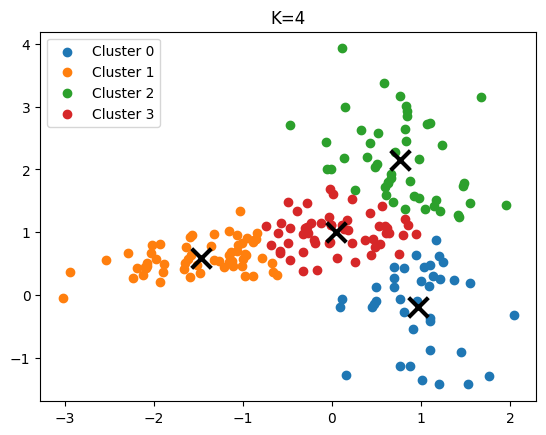

In [10]:
plot_clusters(Xc_2, best_centroids, best_labels)

100


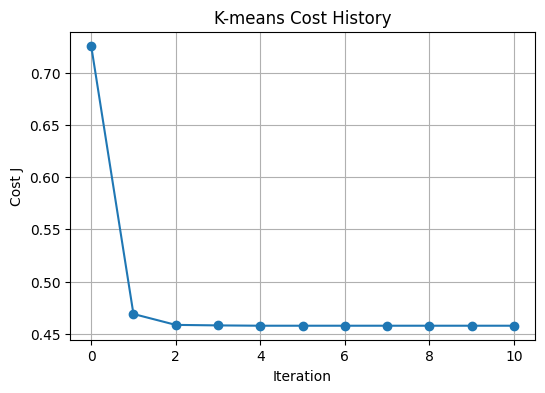

In [11]:
#cost change for the best run 
def plot_cost_history(J_history):
    plt.figure(figsize=(6, 4))
    plt.plot(J_history[:11], marker='o')
    plt.title('K-means Cost History')
    plt.xlabel('Iteration')
    plt.ylabel('Cost J')
    plt.grid()
    plt.show()
print(len(best_J_history))
plot_cost_history(best_J_history)

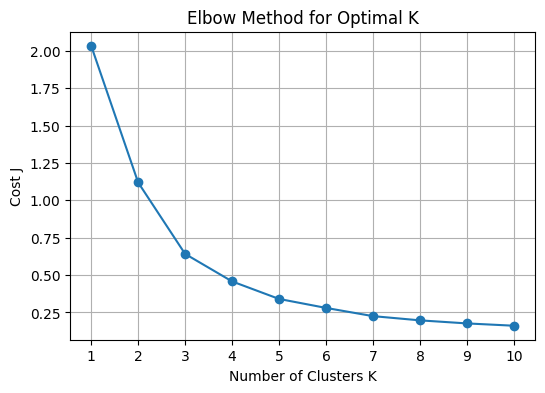

In [12]:
def elbow_method(X, max_K=10, n_runs=10):
    # Run K-means for K=1 to max_K and plot the final cost J for each K
    costs = []
    for K in range(1, max_K + 1):
        _, _, J_history = best_kmeans(X, K=K, n_runs=n_runs)
        costs.append(J_history[-1])
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, max_K + 1), costs, marker='o')
    plt.title('Elbow Method for Optimal K')
    plt.xlabel('Number of Clusters K')
    plt.ylabel('Cost J')
    plt.xticks(range(1, max_K + 1))
    plt.grid()
    plt.show()
    
elbow_method(Xc_2, max_K=10, n_runs=100)

Sklearn KMeans Cost J: 0.47402


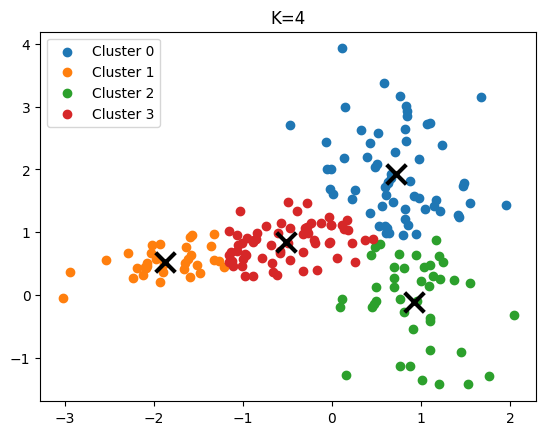

In [13]:
# k_means with sklearn
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=0, n_init='auto').fit(Xc_2)
sklearn_centroids = kmeans.cluster_centers_
sklearn_labels = kmeans.labels_
sklearn_cost = kmeans.inertia_ / len(Xc_2)
print(f'Sklearn KMeans Cost J: {sklearn_cost:.5f}')
plot_clusters(Xc_2, sklearn_centroids, sklearn_labels)